# Überblick: Logistische Regression

## Thema und Ziel
Dieses Notebook zeigt anschaulich, wie eine logistische Regression zwischen zwei Klassen unterscheidet. Mit künstlich erzeugten Daten wird ein Modell trainiert, geprüft und als Wahrscheinlichkeitskurve dargestellt.

## Das lernst du
- Trainings- und Testdaten unterscheiden und ein Modell mit `fit` trainieren.
- Vorhersagen und Klassenwahrscheinlichkeiten mit `predict` und `predict_proba` berechnen.
- Eine Konfusionsmatrix lesen und die Entscheidungsschwelle passend zur Fragestellung verändern.

## Wichtige Begriffe
| Begriff | Einfach erklärt |
|---|---|
| Binäre Klassifikation | Eine Vorhersage mit genau zwei möglichen Klassen, hier 0 und 1. |
| Merkmal (`x`) und Ziel (`y`) | `x` ist die Eingabe; `y` ist die bekannte Klasse, die das Modell lernen soll. |
| Logistische Regression | Ein Modell, das aus Merkmalen eine Wahrscheinlichkeit für eine Klasse berechnet. |
| Sigmoidfunktion | Wandelt einen beliebigen Zahlenwert in eine Wahrscheinlichkeit zwischen 0 und 1 um. |
| Schwellenwert | Ab welcher Wahrscheinlichkeit eine Beobachtung als Klasse 1 gilt; standardmäßig meist 0,5. |
| Konfusionsmatrix | Zeigt richtige und falsche Vorhersagen getrennt nach tatsächlicher und vorhergesagter Klasse. |
| Precision und Recall | Precision beschreibt, wie zuverlässig positive Vorhersagen sind; Recall, wie viele tatsächliche positive Fälle gefunden werden. |

## Zentrale Syntax und benötigte Werte
- `make_classification(...)` erzeugt Beispieldaten. Hier entstehen Eingaben `x` und Klassen `y`; `n_samples`, `n_features` und `n_classes` legen Größe und Aufbau fest.
- `train_test_split(x, y, ...)` teilt Merkmale und Zielwerte in Trainings- und Testdaten auf. Die vier Ergebnisse heißen `X_train`, `X_test`, `y_train` und `y_test`.
- `LogisticRegression()` erstellt das Modell. `lr.fit(X_train, y_train)` lernt dessen Parameter aus den Trainingsdaten.
- `lr.predict(X_test)` sagt Klassen voraus; `lr.predict_proba(X_test)` liefert Wahrscheinlichkeiten für jede Klasse.
- `confusion_matrix(y_test, y_pred)` vergleicht echte Klassen mit Vorhersagen. Beide Arrays müssen dieselben Beobachtungen enthalten.
- `expit(t)` berechnet die Sigmoidfunktion für `t`. Hier wird `t` aus dem Merkmal `x`, dem Koeffizienten `lr.coef_` und dem Achsenabschnitt `lr.intercept_` gebildet.

Code-Zellen führen die einzelnen Schritte aus; Markdown-Zellen erklären den Ablauf und helfen bei der Interpretation.

# Einführung in die logistische Regression

In diesem Notebook lernst du anschaulich, wie die logistische Regression funktioniert.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


Als Nächstes erzeugen wir mit der Funktion `make_classification` aus der Bibliothek scikit-learn Beispieldaten. Die logistische Regression wird häufig für binäre Klassifikationen verwendet. Deshalb besteht unser Datensatz aus zwei Klassen.

In [3]:
# We set a random state so the generated data is the same for each run of this cell
x, y = make_classification(
    n_samples=100,
    n_features=1,
    n_classes=2,
    n_clusters_per_class=1,
    flip_y=0.03,
    n_informative=1,
    n_redundant=0,
    n_repeated=0,
    random_state=3789,
)

In [4]:
data = {"x": x.reshape((100,)), "y": y.reshape((100,))}

In [5]:
df = pd.DataFrame(data=data)
df

,x,y
0,1.071387,1
1,1.637385,1
2,0.946752,1
3,2.302251,1
4,0.528806,1
...,...,...
95,-1.414146,0
96,1.119315,1
97,-1.354310,0
98,0.547361,1


In [6]:
# statistical properties for each class y (0,1)
statistical_properties_for_class = df.groupby(by=["y"])[["x"]].describe()
statistical_properties_for_class

x                                                                      
  count      mean       std       min       25%       50%       75%       max
y                                                                            
0  51.0 -0.807349  0.969754 -2.607748 -1.430320 -0.778034 -0.236799  2.057215
1  49.0  0.891327  0.544230 -0.476926  0.542125  0.965722  1.169664  2.302251

Text(0.5, 1.0, 'Binary Classification Data')

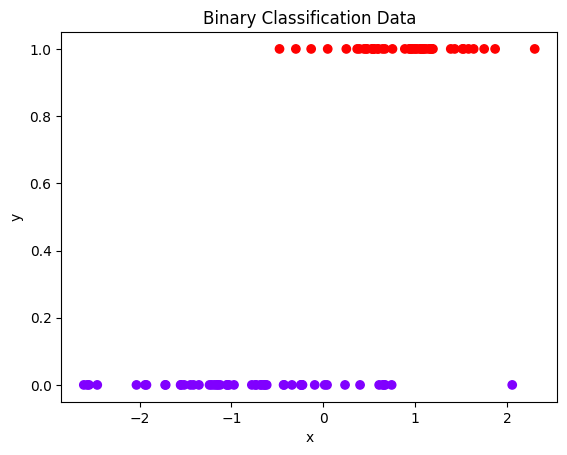

In [7]:
# We plot the relationship between the feature and classes.
plt.scatter(x, y, c=y, cmap="rainbow")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Binary Classification Data")

Die Grafik zeigt einen Datensatz für binäre Klassifikation. Die y-Achse zeigt die tatsächlichen Klassen der einzelnen Datenpunkte. Hier steht `y = 0` für die negative und `y = 1` für die positive Klasse. Die x-Achse zeigt das Merkmal.

Für die Klasse `y = 0` liegen die x-Werte zwischen etwa -2,6 und 2,03. Für die Klasse `y = 1` reichen sie von etwa -0,48 bis 2,30. Weitere statistische Kennzahlen findest du in der Python-Variable `statistical_properties_for_class`.

In [9]:
# Prior to training our model, we’ll set aside a portion of our data in order to evaluate its performance.
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1)

In [10]:
# We instantiate an instance of the LogisticRegression class and call the fit function with the features and the labels
# (since Logistic Regression is a supervised machine learning algorithm) as arguments.

lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [11]:
# We can access the following properties to actually view the model parameter.
print(lr.coef_)
print(lr.intercept_)

[[2.17670904]]
[-0.05053172]


In [20]:
# Let’s see how the model performs against data that it hasn’t been trained on.
y_pred = lr.predict(X_test)
lr.predict(X_test)

array([0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 0])

In [13]:
# Given that this is a classification problem, we use a confusion matrix to evaluate our model.
confusion_matrix(y_test, y_pred)

array([[12,  4],
       [ 0,  9]])

In [14]:
# If for whatever reason we’d like to check the actual probability that a data point belongs to a given class,
# we can use the predict_proba function.
lr.predict_proba(X_test)

array([[0.98583006, 0.01416994],
       [0.1722633 , 0.8277367 ],
       [0.92936602, 0.07063398],
       [0.13216349, 0.86783651],
       [0.68868327, 0.31131673],
       [0.16950854, 0.83049146],
       [0.99632678, 0.00367322],
       [0.9781116 , 0.0218884 ],
       [0.89724063, 0.10275937],
       [0.97782194, 0.02217806],
       [0.63749593, 0.36250407],
       [0.20427251, 0.79572749],
       [0.10820081, 0.89179919],
       [0.8240724 , 0.1759276 ],
       [0.0325385 , 0.9674615 ],
       [0.07544301, 0.92455699],
       [0.30556617, 0.69443383],
       [0.19569622, 0.80430378],
       [0.04877346, 0.95122654],
       [0.24489648, 0.75510352],
       [0.11812855, 0.88187145],
       [0.50429387, 0.49570613],
       [0.95250498, 0.04749502],
       [0.0364039 , 0.9635961 ],
       [0.98626217, 0.01373783]])

In [15]:
pd.DataFrame(lr.predict_proba(X_test))

,0,1
0,0.985830,0.014170
1,0.172263,0.827737
2,0.929366,0.070634
3,0.132163,0.867837
4,0.688683,0.311317
5,0.169509,0.830491
6,0.996327,0.003673
7,0.978112,0.021888
8,0.897241,0.102759
9,0.977822,0.022178


Die erste Spalte enthält die Wahrscheinlichkeit, dass ein Beispiel zur ersten Klasse gehört (hier `y = 0`). Die zweite Spalte enthält die Wahrscheinlichkeit für die zweite Klasse (hier `y = 1`).

Bevor wir die Sigmoidfunktion zeichnen, erstellen wir einen DataFrame mit den Testdaten und sortieren ihn nach `x`. Die Sigmoidfunktion liefert die Wahrscheinlichkeit, dass eine Beobachtung zur positiven Klasse gehört.

In [16]:
df = pd.DataFrame({"x": X_test[:, 0], "y": y_test})
df = df.sort_values(by="x")

In [17]:
df

,x,y
6,-2.550857,0
24,-1.940194,0
0,-1.925765,0
7,-1.722387,0
9,-1.716211,0
22,-1.354310,0
2,-1.160679,0
8,-0.972295,0
13,-0.686198,0
4,-0.341543,0


In [18]:
from scipy.special import expit

sigmoid_function = expit(df["x"] * lr.coef_[0][0] + lr.intercept_[0]).to_numpy()

Die Sigmoidfunktion lautet:
$$\sigma = \dfrac{1}{1+e^{-t}} =  \dfrac{1}{1+e^{-(b_{0} + b_{1}*X)}}$$

Dabei gilt:
- $\sigma$ ist die vorhergesagte Wahrscheinlichkeit, dass die Beobachtung zur positiven Klasse (`y = 1`) gehört.
- $t$ ist die lineare Kombination der Eingabemerkmale: $b_{0} + b_{1}*X$. Dabei ist $b_{0}$ der Achsenabschnitt und $b_{1}$ der Koeffizient des Merkmals $X$.

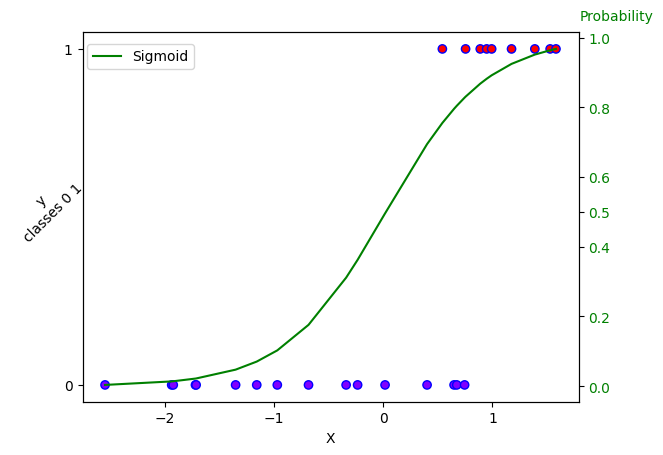

In [21]:
fig, ax = plt.subplots(sharey=True)

# Plot binary classification data
ax.scatter(df["x"], df["y"], c=df["y"], cmap="rainbow", edgecolors="b")
ax.tick_params(axis="y")
ax.set_xlabel("X")
ax.set_ylabel("y\nclasses 0 1", rotation=45)
ax.set_yticks([0.0, 1.0])

# Generate a new Axes instance, on the twin-X axes (same position)
ax2 = ax.twinx()

# Plot sigmoid function, change tick color
ax2.plot(df["x"], sigmoid_function, color="green", label="Sigmoid")
ax2.tick_params(axis="y", labelcolor="green")
ax2.set_yticks(np.insert(ax2.get_yticks()[1:-1], 3, 0.5))
ax2.text(x=1.8, y=1.05, s="Probability", color="Green")

ax2.legend(loc=(0.01, 0.9))
plt.show()

Die Grafik zeigt die tatsächlichen Klassen der Datenpunkte und die Sigmoidkurve. `y = 0` steht für die negative Klasse, `y = 1` für die positive Klasse. Die grüne Kurve zeigt die vorhergesagte Wahrscheinlichkeit. Bei einer Wahrscheinlichkeit von 0,5 liegt die Grenze bei $x = -b_0/b_1 \approx 0.023$. Vier blaue Punkte liegen rechts von dieser Grenze.

**Check your understanding:**
- Welcher Wert von `X` entspricht einem Wahrscheinlichkeitsschwellenwert von 0,5?

<details>
<summary>Show answer</summary>

Die Sigmoidfunktion gibt genau 0,5 zurück, wenn der lineare Term null ist: `b0 + b1*x = 0`. Daraus folgt `x = -b0/b1`. Mit den gelernten Koeffizienten liegt dieser Punkt bei ungefähr `x = 0.023`. Rechts davon ist die vorhergesagte Wahrscheinlichkeit größer als 0,5 (Klasse 1), links davon kleiner als 0,5 (Klasse 0). Dieser x-Wert ist somit die Entscheidungsgrenze für den Schwellenwert 0,5.
</details>

- Wie viele Datenpunkte werden in der Grafik bei einem Wahrscheinlichkeitsschwellenwert von 0,5 falsch klassifiziert?

<details>
<summary>Show answer</summary>

Vier. Bei einem Schwellenwert von 0,5 liegt die Grenze bei `x = 0.023`. Alle Punkte rechts davon werden als Klasse 1 vorhergesagt. Vier tatsächliche Punkte der Klasse 0 (blaue Punkte) liegen rechts von der Grenze und werden daher fälschlich als positiv vorhergesagt (False Positives). Die tatsächlichen Punkte der Klasse 1 liegen hier alle auf der richtigen Seite.
</details>

- Welchen Schwellenwert würdest du wählen, um die Accuracy zu verbessern?

<details>
<summary>Show answer</summary>

Die Accuracy steigt, wenn insgesamt weniger Punkte auf der falschen Seite der Grenze liegen. Hier befinden sich die Fehler unter den Klasse-0-Punkten knapp rechts von `x = 0.023`. Ein höherer Schwellenwert verschiebt die Grenze nach rechts und kann diese blauen Punkte korrekt einordnen. Wird die Grenze zu weit nach rechts verschoben, werden jedoch echte positive Fälle zu False Negatives. Wähle also den Wert, der die Gesamtzahl der Fehler verringert.
</details>

- Welchen Schwellenwert würdest du wählen, um den Recall zu verbessern?

<details>
<summary>Show answer</summary>

Recall ist der Anteil der tatsächlich positiven Fälle, die das Modell erkennt: `TP / (TP + FN)`. Ein niedrigerer Schwellenwert lässt das Modell häufiger Klasse 1 vorhersagen und kann so False Negatives reduzieren. Dafür können mehr False Positives entstehen. Precision und Recall verändern sich bei einer Schwellenwertanpassung oft gegensätzlich.
</details>

# Zusammenfassung: Was zeigt das Beispiel?

- `LogisticRegression` lernt aus den Trainingsdaten einen Koeffizienten und einen Achsenabschnitt. Die Sigmoidfunktion wandelt deren lineare Kombination in eine Wahrscheinlichkeit für Klasse 1 um.
- Bei der Schwelle 0,5 liegt die Entscheidungsgrenze bei `x = -b0/b1`, hier ungefähr bei `x = 0.023`. Rechts davon sagt das Modell Klasse 1 voraus.
- In der gezeigten Grafik liegen vier tatsächliche Klasse-0-Punkte rechts der Grenze. Sie werden als Klasse 1 vorhergesagt und sind damit False Positives. Die Konfusionsmatrix zeigt diese und die übrigen richtigen/falschen Vorhersagen systematisch.
- Ein höherer Schwellenwert sagt seltener Klasse 1 voraus und kann hier die Gesamtzahl der Fehler verringern. Ein niedrigerer Schwellenwert findet mehr positive Fälle und kann den Recall erhöhen, erzeugt aber möglicherweise mehr False Positives.

## Grenzen und praktische Schlussfolgerung
Die Daten sind künstlich, klein und enthalten nur ein Merkmal. Ein passender Schwellenwert hängt davon ab, ob möglichst wenige Fehlalarme oder möglichst wenige übersehene positive Fälle wichtiger sind. Prüfe diese Entscheidung auf zurückgehaltenen Daten und bewerte neben Accuracy auch Precision und Recall. Das Beispiel misst weder Overfitting noch die Leistung über mehrere Cross-Validation-Aufteilungen.